In [1]:
import pandas as pd
import numpy as np

pd.__version__, np.__version__


('2.2.2', '1.26.4')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


### Load the Dataset

In [3]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")


In [4]:
sentiment

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


The sentiment dataset contains daily Bitcoin market sentiment classification (Fear/Greed).

In [5]:
trades

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


The trading dataset contains trade level data for multiple accounts which has features like Execution price, levarage, position size and PnL info.

### Data Inspection

In [6]:
print("Sentiment shape:", sentiment.shape)
display(sentiment.head()) # get first 5 rows
sentiment.info()
print("\nMissing values:\n", sentiment.isna().sum()) # Check null values
print("\nDuplicate rows in trades:", trades.duplicated().sum()) # duplicates

print("\nTrades shape:", trades.shape)
display(trades.head()) # get first 5 rows
trades.info()
print("\nMissing values:\n", trades.isna().sum()) # Check null values
print("Duplicate rows in sentiment:", sentiment.duplicated().sum()) # duplicates

# remove duplicates
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()


Sentiment shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows in trades: 0

Trades shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

The sentiment dataset contains 2,644 daily Bitcoin Fear/Greed records with no missing values.

The trading dataset contains 211,224 transaction-level trades across multiple accounts.

Trades occur multiple times per day, while sentiment is recorded daily.

Therefore, trade data must be converted to datetime and aggregated to a daily trader level to align with market sentiment.

### Convert timestamps and align the dates

In [7]:
# Convert sentiment date to datetime
sentiment['date']=pd.to_datetime(sentiment['date'])

# Convert trade timestamp
#trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# Extract only date
trades['date'] = trades['Timestamp IST'].dt.date

# Check result
trades[['Timestamp IST','date']].head()



,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


### Key Metrics

- Daily PnL per trader (or per account)
- Win rate
- Average trade size
- Leverage distribution
- Number of trades per day
- Long / Short ratio
ratio



In [8]:
daily_trader = trades.groupby(['Account','date']).agg(
    daily_pnl = ('Closed PnL','sum'),
    avg_trade_size = ('Size USD','mean'),
    trades_count = ('Side','count')
).reset_index()

daily_trader.head()


,Account,date,daily_pnl,avg_trade_size,trades_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,5089.718249,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,7976.664412,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,23734.500000,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,28186.666667,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,17248.148148,27


In [9]:
## aggregate trades to daily level because sentiment = daily and Trades = transaction level, so summarize trades at per account per day
# Win trade flag
trades['win'] = trades['Closed PnL'] > 0

# Trade direction flags
trades['long'] = trades['Side'] == 'BUY'
trades['short'] = trades['Side'] == 'SELL'

# Leverage proxy
trades['leverage'] = trades['Size USD'] / trades['Execution Price']

#### 1. Daily PnL per trader

In [10]:
daily_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed PnL':'daily_pnl'}, inplace=True)


#### 2. Win rate

In [11]:
win_rate = trades.groupby(['Account','date'])['win'].mean().reset_index()
win_rate.rename(columns={'win':'win_rate'}, inplace=True)


#### 3. Average Trade Size

In [12]:
avg_trade_size = trades.groupby(['Account','date'])['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)


#### 4. Number or trades per day

In [13]:
trades_per_day = trades.groupby(['Account','date']).size().reset_index(name='trades_per_day')


#### 5. Long/Short ratio

In [14]:
long_short = trades.groupby(['Account','date']).agg({
    'long':'sum',
    'short':'sum'
}).reset_index()

long_short['long_short_ratio'] = long_short['long'] / (long_short['short'] + 1)


#### 6. Leverage Distribution

In [15]:
leverage = trades.groupby(['Account','date'])['leverage'].mean().reset_index()


In [16]:
## Combining all the metrics into one dataset
metrics = daily_pnl.merge(win_rate,on=['Account','date'])
metrics = metrics.merge(avg_trade_size,on=['Account','date'])
metrics = metrics.merge(trades_per_day,on=['Account','date'])
metrics = metrics.merge(long_short,on=['Account','date'])
metrics = metrics.merge(leverage,on=['Account','date'])


In [17]:
metrics

,Account,date,daily_pnl,win_rate,avg_trade_size,trades_per_day,long,short,long_short_ratio,leverage
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,5089.718249,177,0,177,0.000000,1.587571
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,0.000000,7976.664412,68,0,68,0.000000,16.176470
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,0.000000,23734.500000,40,0,40,0.000000,7.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,0.000000,28186.666667,12,12,0,12.000000,8.333333
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,0.444444,17248.148148,27,12,15,0.750000,74.074074
...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,0.390244,2153.859390,82,50,32,1.515152,122.438146
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,0.393023,1495.538419,430,164,266,0.614232,83.109138
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,0.441242,1939.739989,902,432,470,0.917197,103.318653
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,0.520000,1748.805333,75,50,25,1.923077,95.236469


In [18]:
print("metrics:", metrics['date'].dtype)
print("sentiment:", sentiment['date'].dtype)


metrics: object
sentiment: datetime64[ns]


In [19]:
metrics['date'] = pd.to_datetime(metrics['date']).dt.strftime('%Y-%m-%d')
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.strftime('%Y-%m-%d')


In [20]:
## Merge the metrics dataset with Sentiment
final_data = metrics.merge(sentiment,on='date',how='left')

final_data.head()



,Account,date,daily_pnl,win_rate,avg_trade_size,trades_per_day,long,short,long_short_ratio,leverage,timestamp,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,0,177,0.00,1.587571,1.731303e+09,76.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,0,68,0.00,16.176470,1.731821e+09,90.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,0,40,0.00,7.500000,1.731908e+09,83.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,12,0,12.00,8.333333,1.732253e+09,94.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,12,15,0.75,74.074074,1.732599e+09,79.0,Extreme Greed


In [21]:
final_data['classification'].isna().sum()


1

### Part B: Analysis
# Answer these questions with evidence:
- 
Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?- 
Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)-?
Identify 2–3 segments (examples-):
high leverage vs low leverage trad-ers
frequent vs infrequent tra-ders
consistent winners vs inconsistent t
-aders
Provide at least 3 insights backed by charts/tables.



In [22]:
# First, create sentiment groups
# We only need 2 categories:
# Fear → Fear + Extreme Fear
# Greed → Greed + Extreme Greed

In [23]:
def sentiment_group(x):
    if pd.isna(x):
        return 'Unknown'
    elif 'Fear' in x:
        return 'Fear'
    elif 'Greed' in x:
        return 'Greed'
    else:
        return 'Neutral'

final_data['sentiment_group'] = final_data['classification'].apply(sentiment_group)

final_data['sentiment_group'].value_counts()


sentiment_group
Greed      1174
Fear        790
Neutral     376
Unknown       1
Name: count, dtype: int64

In [24]:
## Filter only fear and greed
analysis_data = final_data[final_data['sentiment_group'].isin(['Fear','Greed'])]

analysis_data['sentiment_group'].value_counts()


sentiment_group
Greed    1174
Fear      790
Name: count, dtype: int64

In [25]:
## Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
performance = analysis_data.groupby('sentiment_group')[['daily_pnl','win_rate']].mean()
performance


,daily_pnl,win_rate
sentiment_group,,
Fear,5185.146443,0.357071
Greed,4144.208334,0.362748


Traders earn higher profits during Fear markets but with a lower win rate, while during Greed markets they win slightly more often but make less profit overall.
This shows that fearful markets produce larger but less frequent winning trades (high risk-reward), whereas greedy markets result in more consistent but smaller profits.

In [26]:
## Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
behavior = analysis_data.groupby('sentiment_group')[[
    'trades_per_day',
    'avg_trade_size',
    'long_short_ratio',
    'leverage'
]].mean()

behavior


,trades_per_day,avg_trade_size,long_short_ratio,leverage
sentiment_group,,,,
Fear,105.363291,8529.859802,7.912088,5613.442494
Greed,76.912266,5954.632633,5.434413,8454.221425


Traders are significantly more active during Fear markets, executing more trades and larger position sizes, while using lower leverage.
Whereas, during Greed markets traders trade less frequently and with smaller positions but use higher leverage, which shows overconfidence and risk-seeking behavior

#### High Leverage vs Low Leverage traders

In [27]:
# calculate trader level leverage
trader_leverage = analysis_data.groupby('Account')['leverage'].mean().reset_index()

median_lev = trader_leverage['leverage'].median()

trader_leverage['lev_segment'] = trader_leverage['leverage'].apply(
    lambda x: 'High Leverage' if x >= median_lev else 'Low Leverage'
)

trader_leverage.head()


,Account,leverage,lev_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,19.535371,Low Leverage
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1128.927171,Low Leverage
2,0x271b280974205ca63b716753467d5a371de622ab,183.369870,Low Leverage
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1437.742072,High Leverage
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,23389.784779,High Leverage


In [28]:
analysis_data = analysis_data.merge(trader_leverage[['Account','lev_segment']], on='Account')


In [29]:
lev_perf = analysis_data.groupby('lev_segment')[['daily_pnl','win_rate']].mean()
lev_perf


,daily_pnl,win_rate
lev_segment,,
High Leverage,3749.270512,0.376162
Low Leverage,5616.091760,0.340145


Low-leverage traders actually earn higher profits even though high-leverage traders win slightly more often.

#### Frequent vs Infrequent Traders

In [30]:
trader_freq = analysis_data.groupby('Account')['trades_per_day'].mean().reset_index()

median_freq = trader_freq['trades_per_day'].median()

trader_freq['freq_segment'] = trader_freq['trades_per_day'].apply(
    lambda x: 'Frequent' if x >= median_freq else 'Infrequent'
)

analysis_data = analysis_data.merge(trader_freq[['Account','freq_segment']], on='Account')



In [31]:
freq_perf = analysis_data.groupby('freq_segment')[['daily_pnl','win_rate']].mean()
freq_perf


,daily_pnl,win_rate
freq_segment,,
Frequent,5746.936021,0.410893
Infrequent,3421.519949,0.311851


Traders who trade more often earn much higher profits and also win more trades.
Traders who trade rarely earn less and lose more frequently.

<Axes: title={'center': 'Frequent vs Infrequent Traders'}, xlabel='freq_segment'>

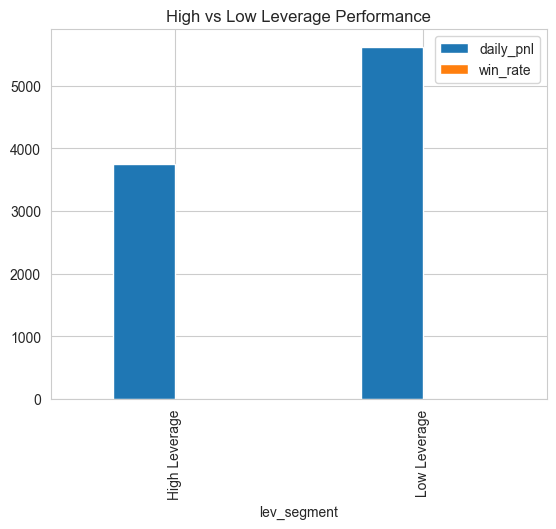

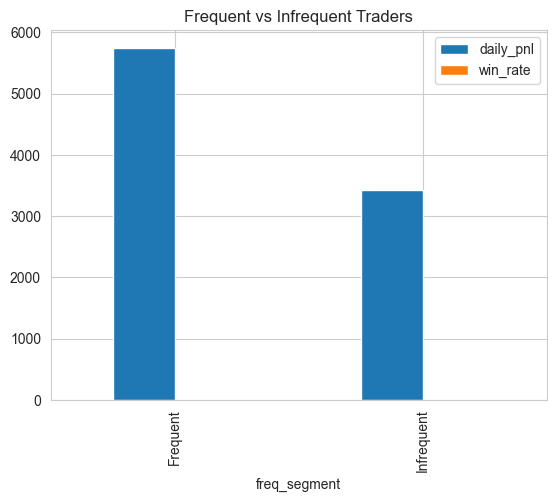

In [32]:
lev_perf.plot(kind='bar', title='High vs Low Leverage Performance')
freq_perf.plot(kind='bar', title='Frequent vs Infrequent Traders')



## Part 3: Actionable Insights
Propose 2 strategy ideas or “rules of thumb” based on your findings. Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.”

Insights from the above data:

Fear → higher profit but lower win rate (big moves)

Greed → smaller profit but higher win rate

Frequent traders perform better

Low leverage traders earn more

Traders over-leverage in Greed

## Strategy 1 — Control risk based on the market mood

Markets also have emotions — sometimes everyone is excited (**Greed**), sometimes everyone is scared (**Fear**).

- In Greed -> people feel over-confident and take big risky trades -> many losses
- In Fear -> prices move a lot -> good chance to earn if you stay controlled
  
- **Greed days:**  
  Trade small and use less leverage (don’t go all-in)

- **Fear days:**  
  You can trade a bit bigger, but still keep control

## Strategy 2 — Adjust how often you trade

Not every day is meant for constant trading.

**What happens:**
- Fear markets move up & down a lot -> many opportunities
- Greed market moves slowly -> too many trades = unnecessary losses

- **Fear days:**  
  Trade more often (small/intraday trades are okay)

- **Greed days:**  
  Trade less 

## summary
- Excited market -> be cautious  
- Scared market -> be active but controlled  
- avoid oversized risk

#### Let's predict the next day profitability using ML Model

In [35]:
# Create the target variable

# Sort data first
analysis_data = analysis_data.sort_values(['Account','date'])

# Next day PnL
analysis_data['next_day_pnl'] = analysis_data.groupby('Account')['daily_pnl'].shift(-1)

# Target: profitable next day (1) or loss (0)
analysis_data['target'] = (analysis_data['next_day_pnl'] > 0).astype(int)

analysis_data[['daily_pnl','next_day_pnl','target']].head()

,daily_pnl,next_day_pnl,target
0,0.0,0.0,0
1,0.0,0.0,0
2,0.0,-21227.0,0
3,-21227.0,1603.1,1
4,1603.1,-132271.0,0


In [37]:
# Select the features
features = [
    'win_rate',
    'avg_trade_size',
    'trades_per_day',
    'long_short_ratio',
    'leverage'
]

X = analysis_data[features]
y = analysis_data['target']

In [38]:
X

,win_rate,avg_trade_size,trades_per_day,long_short_ratio,leverage
0,0.000000,5089.718249,177,0.000000,1.587571
1,0.000000,7976.664412,68,0.000000,16.176470
2,0.000000,23734.500000,40,0.000000,7.500000
3,0.000000,28186.666667,12,12.000000,8.333333
4,0.444444,17248.148148,27,0.750000,74.074074
...,...,...,...,...,...
1959,0.422078,1040.841494,154,0.722222,55.263052
1960,0.068966,1771.744828,29,29.000000,100.030275
1961,0.390244,2153.859390,82,1.515152,122.438146
1962,0.441242,1939.739989,902,0.917197,103.318653


In [39]:
y

0       0
1       0
2       0
3       1
4       0
       ..
1959    1
1960    1
1961    1
1962    1
1963    0
Name: target, Length: 1964, dtype: int32

In [40]:
# Removing missing rows created by shift
model_data = analysis_data.dropna(subset=features + ['target'])

X = model_data[features]
y = model_data['target']

In [42]:
y

0       0
1       0
2       0
3       1
4       0
       ..
1959    1
1960    1
1961    1
1962    1
1963    0
Name: target, Length: 1964, dtype: int32

In [43]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
# Train the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [45]:
# Evaluate the model

from sklearn.metrics import classification_report, accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.5979643765903307
              precision    recall  f1-score   support

           0       0.33      0.06      0.10       149
           1       0.62      0.93      0.74       244

    accuracy                           0.60       393
   macro avg       0.48      0.49      0.42       393
weighted avg       0.51      0.60      0.50       393



In [46]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
0,win_rate,9.762700e-01
2,trades_per_day,2.511136e-03
4,leverage,-1.081890e-07
1,avg_trade_size,-4.306451e-07
3,long_short_ratio,-1.597557e-03


Why I used this model

I used a simple classification model because:

The goal was to quickly check whether trader profit can be predicted or not

It is easy to understand and explain

It works well as a baseline (first reference model) before trying complex models

It helps identify which features matter (such as win rate)

So, this model is mainly used for understanding trader behavior, not for perfect prediction.

Why the accuracy is only ~60%

Trading profit depends on many unpredictable factors, such as:

sudden market movements

news and volatility

trader psychology

timing of entry and exit

The dataset only contains behavior metrics and does not include full market context.
Therefore, the prediction accuracy is limited.�
